In [0]:
import re   # https://justpaste.it/c6u98
import numpy as np
import pandas as pd
from pprint import pprint
from tqdm import tqdm

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords

import gensim
import gensim.corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models import CoherenceModel

from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix , classification_report, accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
# from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier
# from imblearn.over_sampling import RandomOverSampler
import pickle
import spacy
import ast

# import pyLDAvis
# import pyLDAvis.gensim_models  
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', None)


import warnings
warnings.filterwarnings("ignore",category=DeprecationWarning)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dev\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Dev\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [1]:
df = pd.read_csv(r"bbc-text.csv")
df.shape

(2225, 2)

In [2]:
df.head(6)

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...
5,politics,howard hits back at mongrel jibe michael howar...


In [3]:
df["category"].value_counts()

category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

In [4]:
df["text"][0]

'tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in five years  time.  that is according to an expert panel which gathered at the annual consumer electronics show in las vegas to discuss how these new technologies will impact one of our favourite pastimes. with the us leading the trend  programmes and other content will be delivered to viewers via home networks  through cable  satellite  telecoms companies  and broadband service providers to front rooms and portable devices.  one of the most talked-about technologies of ces has been digital and personal video recorders (dvr and pvr). these set-top boxes  like the us s tivo and the uk s sky+ system  allow people to record  store  play  pause and forward wind tv programmes when they want.  essentially  the technology allows for much more personalised tv. they are also being built-in to high

In [5]:
stop_words = stopwords.words('english')
len(stop_words)

198

In [6]:
file = open("stopwords/extended_stopwords.txt", "r")
stop_words.extend([line.strip() for line in file.readlines()])
file.close()

In [7]:
len(stop_words)

1546

In [8]:
file = open("stopwords/contractions.txt", "r")
contractions = ast.literal_eval(file.read())
file.close()

In [9]:
contractions

{"ain't": 'am not',
 "aren't": 'are not',
 "can't": 'cannot',
 'cause': 'because',
 "could've": 'could have',
 "couldn't": 'could not',
 "didn't": 'did not',
 "doesn't": 'does not',
 "don't": 'do not',
 "hadn't": 'had not',
 "hasn't": 'has not',
 "haven't": 'have not',
 "he'd": 'he would',
 "he'll": 'he will',
 "he's": 'he is',
 "how'd": 'how did',
 "i'd": 'i would',
 "i'll": 'i will',
 "i'm": 'i am',
 "i've": 'i have',
 "isn't": 'is not',
 "it'd": 'it would',
 "it'll": 'it will',
 "it's": 'it is',
 "let's": 'let us',
 "ma'am": 'madam',
 "might've": 'might have',
 "must've": 'must have',
 "mustn't": 'must not',
 "needn't": 'need not',
 "o'clock": 'of the clock',
 "shan't": 'shall not',
 "she'd": 'she would',
 "she'll": 'she will',
 "she's": 'she is',
 "should've": 'should have',
 "shouldn't": 'should not',
 "that'd": 'that would',
 "that's": 'that is',
 "there's": 'there is',
 "they'll": 'they will',
 "they're": 'they are',
 "they've": 'they have',
 "wasn't": 'was not',
 "we'd": 'we wo

In [10]:
print(df.category.unique())

['tech' 'business' 'sport' 'entertainment' 'politics']


In [11]:
# Convert to list
data = df.text.values.tolist()
print(len(data))

2225


In [12]:
data[0]

'tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in five years  time.  that is according to an expert panel which gathered at the annual consumer electronics show in las vegas to discuss how these new technologies will impact one of our favourite pastimes. with the us leading the trend  programmes and other content will be delivered to viewers via home networks  through cable  satellite  telecoms companies  and broadband service providers to front rooms and portable devices.  one of the most talked-about technologies of ces has been digital and personal video recorders (dvr and pvr). these set-top boxes  like the us s tivo and the uk s sky+ system  allow people to record  store  play  pause and forward wind tv programmes when they want.  essentially  the technology allows for much more personalised tv. they are also being built-in to high

In [13]:
# Remove Emails
data = [re.sub('\S*@\S*\s?', '', sent) for sent in data]
# Remove new line characters
data = [re.sub('\s+', ' ', sent) for sent in data]
# Remove distracting single quotes
data = [re.sub("\'"," ", sent) for sent in data]
pprint(data[0])

('tv future in the hands of viewers with home theatre systems plasma '
 'high-definition tvs and digital video recorders moving into the living room '
 'the way people watch tv will be radically different in five years time. that '
 'is according to an expert panel which gathered at the annual consumer '
 'electronics show in las vegas to discuss how these new technologies will '
 'impact one of our favourite pastimes. with the us leading the trend '
 'programmes and other content will be delivered to viewers via home networks '
 'through cable satellite telecoms companies and broadband service providers '
 'to front rooms and portable devices. one of the most talked-about '
 'technologies of ces has been digital and personal video recorders (dvr and '
 'pvr). these set-top boxes like the us s tivo and the uk s sky+ system allow '
 'people to record store play pause and forward wind tv programmes when they '
 'want. essentially the technology allows for much more personalised tv. they 

In [14]:
def sent_to_words(sentences):
    for sentence in sentences:
        yield(gensim.utils.simple_preprocess(str(sentence).encode('utf-8'), deacc=True))  # deacc=True removes punctuations

data_words = list(sent_to_words(data))
print(data_words[5])

['howard', 'hits', 'back', 'at', 'mongrel', 'jibe', 'michael', 'howard', 'has', 'said', 'claim', 'by', 'peter', 'hain', 'that', 'the', 'tory', 'leader', 'is', 'acting', 'like', 'an', 'attack', 'mongrel', 'shows', 'labour', 'is', 'rattled', 'by', 'the', 'opposition', 'in', 'an', 'upbeat', 'speech', 'to', 'his', 'party', 'spring', 'conference', 'in', 'brighton', 'he', 'said', 'labour', 'campaigning', 'tactics', 'proved', 'the', 'tories', 'were', 'hitting', 'home', 'mr', 'hain', 'made', 'the', 'claim', 'about', 'tory', 'tactics', 'in', 'the', 'anti', 'terror', 'bill', 'debate', 'something', 'tells', 'me', 'that', 'someone', 'somewhere', 'out', 'there', 'is', 'just', 'little', 'bit', 'rattled', 'mr', 'howard', 'said', 'mr', 'hain', 'leader', 'of', 'the', 'commons', 'told', 'bbc', 'radio', 'four', 'today', 'programme', 'that', 'mr', 'howard', 'stance', 'on', 'the', 'government', 'anti', 'terrorism', 'legislation', 'was', 'putting', 'the', 'country', 'at', 'risk', 'he', 'then', 'accused', 't

In [15]:
# Build the bigram and trigram models
bigram = gensim.models.Phrases(data_words, min_count=5, threshold=100)# higher threshold fewer phrases.
trigram = gensim.models.Phrases(bigram[data_words], threshold=100)  

In [16]:
# Faster way to get a sentence clubbed as a trigram/bigram
bigram_mod = gensim.models.phrases.Phraser(bigram)
trigram_mod = gensim.models.phrases.Phraser(trigram)

In [17]:
# See bigram example
print(bigram_mod[data_words[0]])

['tv', 'future', 'in', 'the', 'hands', 'of', 'viewers', 'with', 'home', 'theatre', 'systems', 'plasma', 'high_definition', 'tvs', 'and', 'digital', 'video_recorders', 'moving', 'into', 'the', 'living_room', 'the', 'way', 'people', 'watch', 'tv', 'will', 'be', 'radically', 'different', 'in', 'five', 'years', 'time', 'that', 'is', 'according', 'to', 'an', 'expert', 'panel', 'which', 'gathered', 'at', 'the', 'annual', 'consumer_electronics', 'show', 'in', 'las_vegas', 'to', 'discuss', 'how', 'these', 'new', 'technologies', 'will', 'impact', 'one', 'of', 'our', 'favourite', 'pastimes', 'with', 'the', 'us', 'leading', 'the', 'trend', 'programmes', 'and', 'other', 'content', 'will', 'be', 'delivered', 'to', 'viewers', 'via', 'home', 'networks', 'through', 'cable', 'satellite', 'telecoms', 'companies', 'and', 'broadband', 'service_providers', 'to', 'front', 'rooms', 'and', 'portable_devices', 'one', 'of', 'the', 'most', 'talked', 'about', 'technologies', 'of', 'ces', 'has', 'been', 'digital',

In [18]:
# Define functions for stopwords, bigrams, trigrams and lemmatization
def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc)) if word not in stop_words] for doc in texts]

def make_bigrams(texts):
    return [bigram_mod[doc] for doc in texts]

def make_trigrams(texts):
    return [trigram_mod[bigram_mod[doc]] for doc in texts]

def lemmatization(texts, allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV']):
    """https://spacy.io/api/annotation"""
    texts_out = []
    for sent in texts:
        doc = nlp(" ".join(sent)) 
        texts_out.append([token.lemma_ for token in doc if token.pos_ in allowed_postags])
    return texts_out

In [19]:
%%time 
# Remove Stop Words
data_words_nostops = remove_stopwords(data_words)

CPU times: total: 28 s
Wall time: 29.3 s


In [20]:
# Form Bigrams
data_words_bigrams = make_bigrams(data_words_nostops)

In [21]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [22]:
# Do lemmatization keeping only noun, adj, vb, adv
data_lemmatized = lemmatization(data_words_bigrams, allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV'])

In [23]:
print(len(data_lemmatized))

2225


In [24]:
data[0]

'tv future in the hands of viewers with home theatre systems plasma high-definition tvs and digital video recorders moving into the living room the way people watch tv will be radically different in five years time. that is according to an expert panel which gathered at the annual consumer electronics show in las vegas to discuss how these new technologies will impact one of our favourite pastimes. with the us leading the trend programmes and other content will be delivered to viewers via home networks through cable satellite telecoms companies and broadband service providers to front rooms and portable devices. one of the most talked-about technologies of ces has been digital and personal video recorders (dvr and pvr). these set-top boxes like the us s tivo and the uk s sky+ system allow people to record store play pause and forward wind tv programmes when they want. essentially the technology allows for much more personalised tv. they are also being built-in to high-definition tv set

In [25]:
" ".join(data_lemmatized[5])

'hit mongrel claim act attack mongrel labour rattle opposition upbeat speech campaigning tactic prove tory hit hain claim tory tactic debate tell bit rattle leader common radio programme stance government anti_terrorism legislation put country risk accuse tory_leader behave attack mongrel play opposition opposition sake tell party labour claim cle office cost year compare shylock fly morning call mongrel tell bit rattle environment reject howard comment tell radio pm programme labour rattle real duty people focus michael_howard record proposal forward country example poor judgement behalf tory policy school taxis immigration crime strike chord voter year election year make political weather tell deny play politic raise case operation cancel time grab headline party week ago hit labour claim plan immigration quota focus medium coverage racist common sense pledge clean hospital school discipline promise rid political correctness national chance decent state education ordinary family teen

In [26]:
# Create Dictionary
id2word = corpora.Dictionary(data_lemmatized)

In [27]:
list(id2word)

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,


In [28]:
# Create Corpusa
texts = data_lemmatized

In [29]:
# Term Document Frequency
corpus = [id2word.doc2bow(text) for text in texts]

In [30]:
# View
print(corpus[0])

[(0, 1), (1, 1), (2, 2), (3, 1), (4, 1), (5, 2), (6, 1), (7, 1), (8, 7), (9, 2), (10, 1), (11, 2), (12, 1), (13, 1), (14, 2), (15, 1), (16, 2), (17, 1), (18, 2), (19, 1), (20, 5), (21, 1), (22, 2), (23, 1), (24, 1), (25, 1), (26, 3), (27, 1), (28, 1), (29, 1), (30, 1), (31, 4), (32, 1), (33, 1), (34, 1), (35, 1), (36, 1), (37, 1), (38, 1), (39, 1), (40, 1), (41, 4), (42, 1), (43, 1), (44, 1), (45, 1), (46, 1), (47, 1), (48, 1), (49, 1), (50, 2), (51, 1), (52, 1), (53, 2), (54, 1), (55, 1), (56, 1), (57, 2), (58, 1), (59, 2), (60, 1), (61, 2), (62, 1), (63, 1), (64, 2), (65, 2), (66, 1), (67, 2), (68, 3), (69, 1), (70, 1), (71, 1), (72, 1), (73, 1), (74, 1), (75, 2), (76, 1), (77, 1), (78, 1), (79, 1), (80, 1), (81, 3), (82, 2), (83, 2), (84, 1), (85, 1), (86, 1), (87, 1), (88, 2), (89, 1), (90, 1), (91, 1), (92, 2), (93, 2), (94, 1), (95, 1), (96, 1), (97, 5), (98, 1), (99, 1), (100, 2), (101, 1), (102, 1), (103, 2), (104, 7), (105, 1), (106, 1), (107, 1), (108, 3), (109, 1), (110, 1),

In [31]:
id2word[0]

'abide'

In [32]:
# Human readable format of corpus (term-frequency)
[[(id2word[id], freq) for id, freq in cp] for cp in corpus[:1]]

[[('abide', 1),
  ('advert', 1),
  ('advertising', 2),
  ('announce', 1),
  ('annual', 1),
  ('big', 2),
  ('bill_gate', 1),
  ('box', 1),
  ('brand', 7),
  ('broadband', 2),
  ('broadcaster', 1),
  ('build', 2),
  ('business', 1),
  ('button', 1),
  ('cable', 2),
  ('call', 1),
  ('capability', 2),
  ('carte', 1),
  ('ce', 2),
  ('challenge', 1),
  ('channel', 5),
  ('chief', 1),
  ('choice', 2),
  ('comfortable', 1),
  ('commercial', 1),
  ('communication', 1),
  ('company', 3),
  ('concern', 1),
  ('connection', 1),
  ('consumer', 1),
  ('consumer_electronic', 1),
  ('content', 4),
  ('control', 1),
  ('crystal', 1),
  ('deliver', 1),
  ('device', 1),
  ('diaper', 1),
  ('digital', 1),
  ('directtv', 1),
  ('discuss', 1),
  ('display', 1),
  ('dvr', 4),
  ('enhance', 1),
  ('entertainment', 1),
  ('essentially', 1),
  ('experience', 1),
  ('expert', 1),
  ('external', 1),
  ('familiar', 1),
  ('favourite', 1),
  ('find', 2),
  ('firm', 1),
  ('forget', 1),
  ('forward', 2),
  ('free

In [33]:
def tune_model(dictionary, corpus, texts, limit, start=2, step=1):
    
    coherence_values = []
    model_list = []
    for num_topics in tqdm(range(start, limit, step)):
        model = gensim.models.ldamodel.LdaModel(corpus=corpus,
                                           id2word=dictionary,
                                           num_topics=num_topics, 
                                           random_state=100,
                                           update_every=1,
                                           chunksize=100,
                                           passes=10,
                                           alpha='auto',
                                           per_word_topics=True)
        model_list.append(model)
        coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_values.append(round(coherencemodel.get_coherence(),3))

    return model_list, coherence_values

In [34]:
# Can take a long time to run
model_list, coherence_values = tune_model(dictionary=id2word, 
                                          corpus=corpus, 
                                          texts=data_lemmatized, 
                                          start=2, 
                                          limit=8, 
                                          step=1)

100%|████████████████████████████████████████████████████████████████████████████████████| 6/6 [05:21<00:00, 53.55s/it]


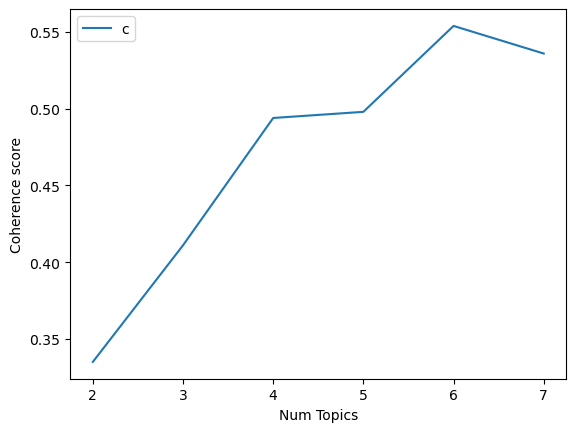

In [35]:
# Show graph
limit=8; start=2; step=1;
x = range(start, limit, step)
plt.plot(x, coherence_values)
plt.xlabel("Num Topics")
plt.ylabel("Coherence score")
plt.legend(("coherence_values"), loc='best')
plt.show()

In [36]:
# Print the coherence scores
for m, cv in zip(x, coherence_values):
    print("Num Topics =", m, " has Coherence Value of", round(cv, 4))

Num Topics = 2  has Coherence Value of 0.335
Num Topics = 3  has Coherence Value of 0.411
Num Topics = 4  has Coherence Value of 0.494
Num Topics = 5  has Coherence Value of 0.498
Num Topics = 6  has Coherence Value of 0.554
Num Topics = 7  has Coherence Value of 0.536


In [45]:
optimal_model = model_list[4]
model_topics = optimal_model.show_topics(formatted=False)
pprint(optimal_model.print_topics(num_words=10))

[(0,
  '0.008*"government" + 0.008*"people" + 0.007*"work" + 0.006*"plan" + '
  '0.005*"year" + 0.005*"law" + 0.005*"tell" + 0.005*"country" + 0.005*"case" '
  '+ 0.004*"rule"'),
 (1,
  '0.019*"game" + 0.016*"play" + 0.013*"player" + 0.013*"time" + 0.012*"year" '
  '+ 0.011*"win" + 0.008*"team" + 0.007*"match" + 0.007*"club" + 0.007*"good"'),
 (2,
  '0.017*"people" + 0.009*"technology" + 0.007*"service" + 0.007*"computer" + '
  '0.007*"net" + 0.007*"mobile" + 0.007*"network" + 0.007*"user" + '
  '0.007*"firm" + 0.006*"phone"'),
 (3,
  '0.021*"year" + 0.014*"sale" + 0.014*"rise" + 0.012*"company" + 0.009*"firm" '
  '+ 0.009*"expect" + 0.008*"market" + 0.008*"fall" + 0.008*"share" + '
  '0.007*"price"'),
 (4,
  '0.025*"labour" + 0.022*"party" + 0.018*"election" + 0.013*"tory" + '
  '0.012*"people" + 0.011*"vote" + 0.010*"tony_blair" + 0.009*"conservative" + '
  '0.009*"government" + 0.008*"plan"'),
 (5,
  '0.035*"film" + 0.016*"year" + 0.013*"music" + 0.012*"award" + 0.011*"star" '
  '+ 

In [46]:
x = optimal_model.show_topics(num_topics=6, num_words=10, formatted=False)
topics_words = [(tp[0], [wd[0] for wd in tp[1]]) for tp in x]

# Below Code Prints Topics and Words
for topic, words in topics_words:
    print(str(topic) + "::" + str(words))
    print()
print()

print("---------------------")

0::['government', 'people', 'work', 'plan', 'year', 'law', 'tell', 'country', 'case', 'rule']

1::['game', 'play', 'player', 'time', 'year', 'win', 'team', 'match', 'club', 'good']

2::['people', 'technology', 'service', 'computer', 'net', 'mobile', 'network', 'user', 'firm', 'phone']

3::['year', 'sale', 'rise', 'company', 'firm', 'expect', 'market', 'fall', 'share', 'price']

4::['labour', 'party', 'election', 'tory', 'people', 'vote', 'tony_blair', 'conservative', 'government', 'plan']

5::['film', 'year', 'music', 'award', 'star', 'include', 'top', 'dance', 'number', 'song']


---------------------


In [47]:
['tech', 'business', 'sport', 'entertainment', 'politics'

SyntaxError: incomplete input (294874628.py, line 1)

In [48]:
labels = {2:"tech",0:"politics1",1:"sports",3:"business",4:"politics2",5:"entertainment"}

In [49]:
df["category"].unique()

array(['tech', 'business', 'sport', 'entertainment', 'politics'],
      dtype=object)

In [50]:
import operator
from functools import reduce
from collections import defaultdict

In [51]:
def format_topics_sentences(ldamodel=optimal_model, corpus=corpus, texts=data):  # https://justpaste.it/h9js4
    # Init output
    sent_topics_df = pd.DataFrame()

    # Get main topic in each document
    for i, row in enumerate(ldamodel[corpus]):
        
        row = sorted(row[0], key=lambda x: x[1], reverse=True)
        # Get the Dominant topic, Perc Contribution and Keywords for each document
        for j, (topic_num, prop_topic) in enumerate(row):
            if j == 0:  # => dominant topic
                wp = ldamodel.show_topic(topic_num)
                topic_keywords = ", ".join([word for word, prop in wp])
                sent_topics_df = sent_topics_df._append(pd.Series([int(topic_num), round(prop_topic,4), topic_keywords]), ignore_index=True)
            else:
                break
    sent_topics_df.columns = ['Dominant_Topic', 'Perc_Contribution', 'Topic_Keywords']

    # Add original text to the end of the output
    contents = pd.Series(texts)
    sent_topics_df = pd.concat([sent_topics_df, contents], axis=1)
    return(sent_topics_df)


df_topic_sents_keywords = format_topics_sentences(ldamodel=optimal_model, corpus=corpus, texts=data)

# Format
df_dominant_topic = df_topic_sents_keywords.reset_index()
df_dominant_topic.columns = ['Document_No', 'Topic_No', 'Topic_Perc_Contrib', 'Topic_Keywords', 'Text']

final_df = df_dominant_topic.drop("Document_No", axis=1)

# add clean text Show
clean_text = [ " ".join(i) for i in texts]
final_df["Clean_Text"] = clean_text
final_df["Topic Name"] = final_df["Topic_No"].replace(labels)
final_df["Atucal Topic"] = df["category"].values
# show
final_df.head(10)

,Topic_No,Topic_Perc_Contrib,Topic_Keywords,Text,Clean_Text,Topic Name,Atucal Topic
0,2,0.8649,"people, technology, service, computer, net, mo...",tv future in the hands of viewers with home th...,tv future hand viewer theatre system plasma hi...,tech,tech
1,0,0.7391,"government, people, work, plan, year, law, tel...",worldcom boss left books alone former worldcom...,boss leave book ebber accuse oversee fraud acc...,politics1,business
2,1,0.6839,"game, play, player, time, year, win, team, mat...",tigers wary of farrell gamble leicester say th...,tiger wary gamble leicester rush make bid deci...,sports,sport
3,1,0.9086,"game, play, player, time, year, win, team, mat...",yeading face newcastle in fa cup premiership s...,yeade face newcastle premiership side trip rym...,sports,sport
4,5,0.8750,"film, year, music, award, star, include, top, ...",ocean s twelve raids box office ocean s twelve...,raid box_office crime caper sequel star cloone...,entertainment,entertainment
5,4,0.5793,"labour, party, election, tory, people, vote, t...",howard hits back at mongrel jibe michael howar...,hit mongrel claim act attack mongrel labour ra...,politics2,politics
6,0,0.5510,"government, people, work, plan, year, law, tel...",blair prepares to name poll date tony blair is...,prepare poll tony_blair election day parliamen...,politics1,politics
7,1,0.8632,"game, play, player, time, year, win, team, mat...",henman hopes ended in dubai third seed tim hen...,hope end seed tim_henman slump straight set de...,sports,sport
8,1,0.8716,"game, play, player, time, year, win, team, mat...",wilkinson fit to face edinburgh england captai...,long_awaite return play injure full contact tr...,sports,sport
9,2,0.3389,"people, technology, service, computer, net, mo...",last star wars not for children the sixth and ...,star_war child sixth final star_war movie suit...,tech,entertainment


In [ ]:
final_df["Topic_No"].value_counts()

In [ ]:

from rake_nltk import Rake

# Uses stopwords for english from NLTK, and all puntuation characters by
# default
r = Rake()

# Extraction given the text.
print(r.extract_keywords_from_text('boss leave book ebber accuse oversee fraud accounting decision witness tell comment question defence lawyer argue ebber responsible worldcom problem phone company collapse prosecutor claim loss hide protect firm share myer pleaded_guilty fraud assist defence distance client allegation cross examination ask know ebber accounting decision aware myer reply ebber account entry book weingarten press reply witness admit order false accounting entry request defence lawyer paint admit fraud testify trial mastermind house card ebber team portray affable boss admission ability ebber transform unknown telecoms_giant investor darling late problem mount competition increase telecom boom petere firm collapse shareholder lose worker lose job ebber trial expect month guilty ceo face substantial firmly declare innocence'))
# Create Dictionary')

# r.extract_keywords_from_sentences()

# Classification 

In [ ]:
from gensim.models import Word2Vec  
from sklearn.feature_extraction.text import TfidfVectorizer   
import pickle
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

In [ ]:
# Classification using TFIDF vectorizer

# Vectorize training and testing data. Here we would pass TfidfVectorizer() to vec 
def Vectorize(vec, X_train, X_test):    
    
    X_train_vec = vec.fit_transform(X_train)
    X_test_vec = vec.transform(X_test)
    
    print('Vectorization complete.\n')
    
    
    return X_train_vec, X_test_vec


In [ ]:
# Use multiple classifiers and grid search for prediction
def ML_modeling(models, params, X_train, X_test, y_train, y_test):    
    
    if not set(models.keys()).issubset(set(params.keys())):
        raise ValueError('Some estimators are missing parameters')

    for key in models.keys():
    
        model = models[key]
        param = params[key]
        gs = GridSearchCV(model, param, cv=5, error_score=0, refit=True)
        gs.fit(X_train, y_train)
        y_pred = gs.predict(X_test)
        
        # Print scores for the classifier
        print(key, ':', gs.best_params_)
        print("Accuracy: %1.3f \tPrecision: %1.3f \tRecall: %1.3f \t\tF1: %1.3f\n" % (accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, average='macro'), recall_score(y_test, y_pred, average='macro'), f1_score(y_test, y_pred, average='macro')))
    
    return

In [ ]:
## Preparing to make a pipeline 
models = {
    'Naive Bayes': MultinomialNB(), 
    'Decision Tree': DecisionTreeClassifier(),  
#     'Perceptron': MLPClassifier(),
    'Gradient Boosting': GradientBoostingClassifier()   ## This model would take a little longer to run 
}

params = {
    'Naive Bayes': { 'alpha': [0.5, 1], 'fit_prior': [True, False] }, 
    'Decision Tree': { 'min_samples_split': [1, 2, 5] }, 
#     'Perceptron': { 'alpha': [0.0001, 0.001], 'activation': ['tanh', 'relu'] },
    'Gradient Boosting': { 'learning_rate': [0.05, 0.1], 'min_samples_split': [2, 5] }
}


# Encode label categories to numbers
enc = LabelEncoder()
final_df['Topic_No'] = enc.fit_transform(final_df['Topic_No'])
labels = list(enc.classes_)

print(labels)

In [ ]:
# Train-test split and vectorize
X_train, X_test, y_train, y_test = train_test_split(final_df['Text'], final_df['Topic_No'], test_size=0.2, shuffle=True)
X_train_vec, X_test_vec = Vectorize(TfidfVectorizer(), X_train, X_test)

ML_modeling(models, params, X_train_vec, X_test_vec, y_train, y_test)
## ML_modeling method also prints performance scores for each classifier

In [ ]:
with open('filename.pickle', 'rb') as handle:
    b = pickle.load(handle)

In [ ]:
# Train-test split and vectorize
X_train, X_test, y_train, y_test = train_test_split(final_df['Text'], final_df['Topic_No'], test_size=0.2, shuffle=True)
X_train_vec, X_test_vec = Vectorize(TfidfVectorizer(), X_train, X_test)

ML_modeling(models, params, X_train_vec, X_test_vec, y_train, y_test)

In [ ]:
# Vectorize training and testing data. Here we would pass TfidfVectorizer() to vec 
def Vectorize(vec, X_train, X_test):    
    
    X_train_vec = vec.fit_transform(X_train)
    X_test_vec = vec.transform(X_test)
    
    with open('Vectorizer.pickle', 'wb') as handle:
        pickle.dump(vec, handle, protocol=pickle.HIGHEST_PROTOCOL)
    
    print('Vectorization complete.\n')
    
    
    return X_train_vec, X_test_vec

def build_model(models, params, X_train, X_test, y_train, y_test):
    if not set(models.keys()).issubset(set(params.keys())):
        raise ValueError('Some estimators are missing parameters')

    for key in models.keys():
    
        model = models[key]
        param = params[key]
        gs = GridSearchCV(model, param, cv=5, error_score=0, refit=True)
        gs.fit(X_train, y_train)
        y_pred = gs.predict(X_test)
        
        
        
        # Print scores for the classifier
        print(key, ':', gs.best_params_)
        print("Accuracy: %1.3f \tPrecision: %1.3f \tRecall: %1.3f \t\tF1: %1.3f\n" % (accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, average='macro'), recall_score(y_test, y_pred, average='macro'), f1_score(y_test, y_pred, average='macro')))
    
    # dump model
    with open('model.pickle', 'wb') as handle:
        pickle.dump(gs, handle, protocol=pickle.HIGHEST_PROTOCOL)
    print("Model saved..")
    
    return gs

def clean_input(data):
#     data = re.sub(r"\b" + key + r"\b", value, data.lower())
    data = re.sub("\s+", " ", str(data))
    data = re.sub("\S*@\S*\s?", "", str(data))
    data = re.sub(r"https?://\S+|www\.\S+", "", str(data))
    data = re.sub("(\\d|\\W)+", " ", str(data))
    data = re.sub("'", "", data)
    
    return data

In [ ]:
# Train-test split and vectorize
X_train, X_test, y_train, y_test = train_test_split(final_df['Clean_Text'], final_df['Topic_No'], test_size=0.2, shuffle=True)
X_train_vec, X_test_vec = Vectorize(TfidfVectorizer(), X_train, X_test)

models = {
    'Naive Bayes': MultinomialNB()
}

params = {
    'Naive Bayes': { 'alpha': [0.5, 1], 'fit_prior': [True, False] } 
}

model = build_model(models, params, X_train_vec, X_test_vec, y_train, y_test)

In [ ]:
input_text = """
Computer technology is leading to more accurate sizing and rating methods for process equipment. Heat exchangers are designed with high-precision prediction methods and complex numerical techniques to account for the local flow and temperature conditions. Fouling mitigation is just changing from an art to a science-based technology. The real benefits of sophisticated design codes will not be achieved without reliable fouling prediction methods and mitigation techniques that can be incorporated into the design phase. Recent developments in the computer technology provide an opportunity to productively use fouling information that is scattered in the literature, industry log books, and in reports. A long-term goal for the industry is to develop a knowledge-based system for designing and operating heat exchangers with a minimum impact of water fouling. The major challenges to develop the knowledge-based system are as follows:
Compilation and organization of the fouling data
Easy access by both research organizations and industry
Development of a logic system for interpreting the fouling data
Industrial acceptance of such knowledge-based systems
The fouling data and analyses reported in the literature are often inadequately utilized. To effectively utilize these data, compilation and organization of fouling information are major tasks and challenges for research organizations and industries. This task is more important for the fouling-mitigation technology as compared to other engineering areas. It is hard to imagine that there could be a single correlation with a given set of parameters that can be used to predict the rate of fouling or determine the threshold fouling conditions. One has to rely on the best possible approach to mitigate fouling for a given set of conditions. In the absence of such information, either mitigation methods are overutilized, with high chemical costs, or underutilized, with high maintenance and production costs. Perrakis et al. [54] introduced an approach for compiling the fouling data in the literature. A major cooperative effort is required to carry out such a major challenge for compiling and organizing data. The fouling data and analyses must be accompanied with physical and chemical parameters without which the data have little value.
"""

In [ ]:
# load model file
with open('model.pickle', 'rb') as handle:
    NB_model = pickle.load(handle)
    
# load vectorizer file
with open('Vectorizer.pickle', 'rb') as handle:
    vect = pickle.load(handle)

In [ ]:
feat =  vect.transform([clean_input(input_text)]).toarray()
pred = NB_model.predict(feat)
pred